In [1]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torchvision.ops import deform_conv2d
from sklearn.metrics import auc
import timm

# ==========================================
#      1. MODEL ARCHITECTURE (Required)
# ==========================================
class CrossAttentionFusion(nn.Module):
    def __init__(self, dim, num_heads=4, qkv_bias=False):
        super().__init__()
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        self.q_proj = nn.Linear(dim, dim, bias=qkv_bias)
        self.k_proj = nn.Linear(dim, dim, bias=qkv_bias)
        self.v_proj = nn.Linear(dim, dim, bias=qkv_bias)
        self.proj = nn.Linear(dim, dim)
        self.norm = nn.LayerNorm(dim)
        
        # Hooks for GMAR
        self.attn_map = None
        self.attn_gradients = None

    def save_attn_gradients(self, grad):
        self.attn_gradients = grad

    def forward(self, x_local, x_global):
        B, C, H, W = x_local.shape
        x_local_flat = x_local.flatten(2).transpose(1, 2)
        B_v, N_vit, C_v = x_global.shape
        
        q = self.q_proj(x_local_flat).reshape(B, H*W, self.num_heads, C // self.num_heads).permute(0, 2, 1, 3)
        k = self.k_proj(x_global).reshape(B, N_vit, self.num_heads, C // self.num_heads).permute(0, 2, 1, 3)
        v = self.v_proj(x_global).reshape(B, N_vit, self.num_heads, C // self.num_heads).permute(0, 2, 1, 3)
        
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        
        if attn.requires_grad:
            attn.register_hook(self.save_attn_gradients)
            self.attn_map = attn
            
        x = (attn @ v).transpose(1, 2).reshape(B, H*W, C)
        x = self.proj(x)
        x = self.norm(x + x_local_flat)
        x = x.transpose(1, 2).reshape(B, C, H, W)
        return x

class LocalCNNBranch(nn.Module):
    def __init__(self, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
            # Index 6: The target for Grad-CAM
            nn.Conv2d(256, out_dim, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(out_dim), nn.SiLU()
        )
    def forward(self, x): return self.net(x)

class DeformableDCNNHead(nn.Module):
    def __init__(self, dim, num_classes):
        super().__init__()
        self.offset_conv = nn.Conv2d(dim, 2 * 3 * 3, kernel_size=3, padding=1)
        self.deform_weight = nn.Parameter(torch.Tensor(dim, dim, 3, 3))
        nn.init.kaiming_uniform_(self.deform_weight, nonlinearity='relu')
        self.bn = nn.BatchNorm2d(dim)
        self.act = nn.GELU()
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(dim, num_classes)
    def forward(self, x):
        offsets = self.offset_conv(x)
        x = deform_conv2d(x, offsets, self.deform_weight, padding=1)
        x = self.act(self.bn(x))
        x = self.global_pool(x).flatten(1)
        return self.classifier(x)

class HybridEva02_DCNN_GMAR(nn.Module):
    def __init__(self, model_name, num_classes, pretrained=False):
        super().__init__()
        self.vit = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        self.embed_dim = self.vit.num_features
        self.cnn = LocalCNNBranch(out_dim=self.embed_dim)
        self.fusion = CrossAttentionFusion(dim=self.embed_dim)
        self.head = DeformableDCNNHead(dim=self.embed_dim, num_classes=num_classes)

    def forward(self, x):
        x_vit = self.vit.forward_features(x)[:, 1:, :]
        x_cnn = self.cnn(x)
        x_fused = self.fusion(x_local=x_cnn, x_global=x_vit)
        logits = self.head(x_fused)
        return logits


In [2]:

# ==========================================
#          2. XAI HELPER CLASSES
# ==========================================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.handle_f = self.target_layer.register_forward_hook(self.save_activation)
        self.handle_b = self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output): self.activations = output
    def save_gradient(self, module, grad_input, grad_output): self.gradients = grad_output[0]
    def remove_hooks(self):
        self.handle_f.remove()
        self.handle_b.remove()

    def __call__(self, x, class_idx=None):
        self.model.eval()
        self.model.zero_grad()
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(dim=1)
        logits[0, class_idx].backward()
        
        grads = self.gradients[0].cpu().data.numpy()
        fmaps = self.activations[0].cpu().data.numpy()
        
        weights = np.mean(grads, axis=(1, 2))
        cam = np.zeros(fmaps.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * fmaps[i, :, :]
            
        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

def get_gmar_map(model, x, target_class_idx=None):
    """Retrieves the Gradient-Weighted Cross Attention Map."""
    model.eval()
    model.zero_grad()
    x.requires_grad = True
    logits = model(x)
    if target_class_idx is None:
        target_class_idx = logits.argmax(dim=1).item()
    logits[0, target_class_idx].backward()
    
    attn_map = model.fusion.attn_map
    attn_grad = model.fusion.attn_gradients
    
    # GMAR Formula: ReLU(Gradients) * Attention
    cams = torch.clamp(attn_grad * attn_map, min=0)
    cams = cams.mean(dim=1) # Avg Heads
    gmar_map = cams.mean(dim=2) # Avg Global tokens
    
    grid_size = int(np.sqrt(gmar_map.shape[1]))
    gmar_map = gmar_map.reshape(grid_size, grid_size)
    
    heatmap = cv2.resize(gmar_map.cpu().detach().numpy(), (224, 224))
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    return heatmap, logits

def perturbation_test(model, img_tensor, heatmap, steps=10):
    model.eval()
    with torch.no_grad():
        orig_logits = model(img_tensor)
        orig_probs = torch.softmax(orig_logits, dim=1)
        pred_class = orig_logits.argmax(dim=1).item()
        orig_conf = orig_probs[0, pred_class].item()

    flat = heatmap.flatten()
    total_pixels = flat.shape[0]
    confidences = [orig_conf]
    percentages = [0]
    img_clone = img_tensor.clone()
    
    for i in range(1, steps + 1):
        percent = i * 0.1
        k = int(total_pixels * percent)
        if k == 0: continue
        threshold = np.sort(flat)[-k]
        mask = torch.from_numpy(heatmap > threshold).to(img_tensor.device)
        img_clone[:, :, mask] = 0 
        
        with torch.no_grad():
            new_logits = model(img_clone)
            new_probs = torch.softmax(new_logits, dim=1)
            new_conf = new_probs[0, pred_class].item()
            
        confidences.append(new_conf)
        percentages.append(percent)
        
    drops = [orig_conf - c for c in confidences]
    score = auc(percentages, drops)
    return score, percentages, confidences


In [3]:

# ==========================================
#     3. THE REQUESTED PIPELINE FUNCTION
# ==========================================

def run_full_xai_pipeline(model, img_tensor, label_name, device):
    # 1. Initialize Grad-CAM on the last conv layer of the CNN branch
    # In our HybridEva02 model, the last Conv is at model.cnn.net[6]
    target_layer = model.cnn.net[6]
    gradcam = GradCAM(model, target_layer) 
    
    # 2. Get Explanations
    # A. Grad-CAM
    map_gradcam = gradcam(img_tensor)
    gradcam.remove_hooks() # Clean up hooks
    
    # B. Cross-Attention (Using GMAR for best results)
    map_crossattn, logits = get_gmar_map(model, img_tensor)
    
    # 3. Quantitative Check (Perturbation)
    print("Running Perturbation Analysis...")
    score_gc, pct_gc, conf_gc = perturbation_test(model, img_tensor, map_gradcam)
    score_ca, pct_ca, conf_ca = perturbation_test(model, img_tensor, map_crossattn)
    
    print(f" Perturbation AUC Scores -> Grad-CAM: {score_gc:.4f} | Cross-Attn: {score_ca:.4f}")
    if score_ca > score_gc:
        print(" SUCCESS: Cross-Attention is more faithful!")
    else:
        print(" NOTE: Grad-CAM performed better on this specific sample.")
    
    # 4. Visualization
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    img_disp = inv_normalize(img_tensor[0]).cpu().detach().permute(1, 2, 0).numpy()
    img_disp = np.clip(img_disp, 0, 1)
    
    # Overlay Helper
    def overlay(img, mask, colormap=cv2.COLORMAP_JET):
        heatmap = cv2.applyColorMap(np.uint8(255 * mask), colormap)
        heatmap = np.float32(heatmap) / 255
        cam = heatmap + np.float32(img)
        cam = cam / np.max(cam)
        return cam

    vis_gc = overlay(img_disp, map_gradcam)
    vis_ca = overlay(img_disp, map_crossattn)
    
    # Plotting
    plt.figure(figsize=(16, 5))
    
    # Original
    plt.subplot(1, 4, 1)
    plt.imshow(img_disp)
    plt.title(f"Original: {label_name}")
    plt.axis('off')
    
    # Grad-CAM
    plt.subplot(1, 4, 2)
    plt.imshow(vis_gc)
    plt.title(f"Grad-CAM (Baseline)\nFaithfulness AUC: {score_gc:.3f}")
    plt.axis('off')
    
    # Cross-Attention
    plt.subplot(1, 4, 3)
    plt.imshow(vis_ca)
    plt.title(f"Cross-Attention (GMAR)\nFaithfulness AUC: {score_ca:.3f}")
    plt.axis('off')
    
    # Perturbation Graph
    plt.subplot(1, 4, 4)
    plt.plot(pct_gc, conf_gc, label='Grad-CAM', color='red', marker='o', linestyle='--')
    plt.plot(pct_ca, conf_ca, label='Cross-Attn', color='green', marker='x', linewidth=2)
    plt.xlabel('Masking Percentage')
    plt.ylabel('Model Confidence')
    plt.title('Perturbation Analysis\n(Steeper Drop = Better)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


Loading Model...
Running Full Pipeline on Image 41 (Glioma)...
Running Perturbation Analysis...
 Perturbation AUC Scores -> Grad-CAM: 0.1081 | Cross-Attn: 0.4079
 SUCCESS: Cross-Attention is more faithful!


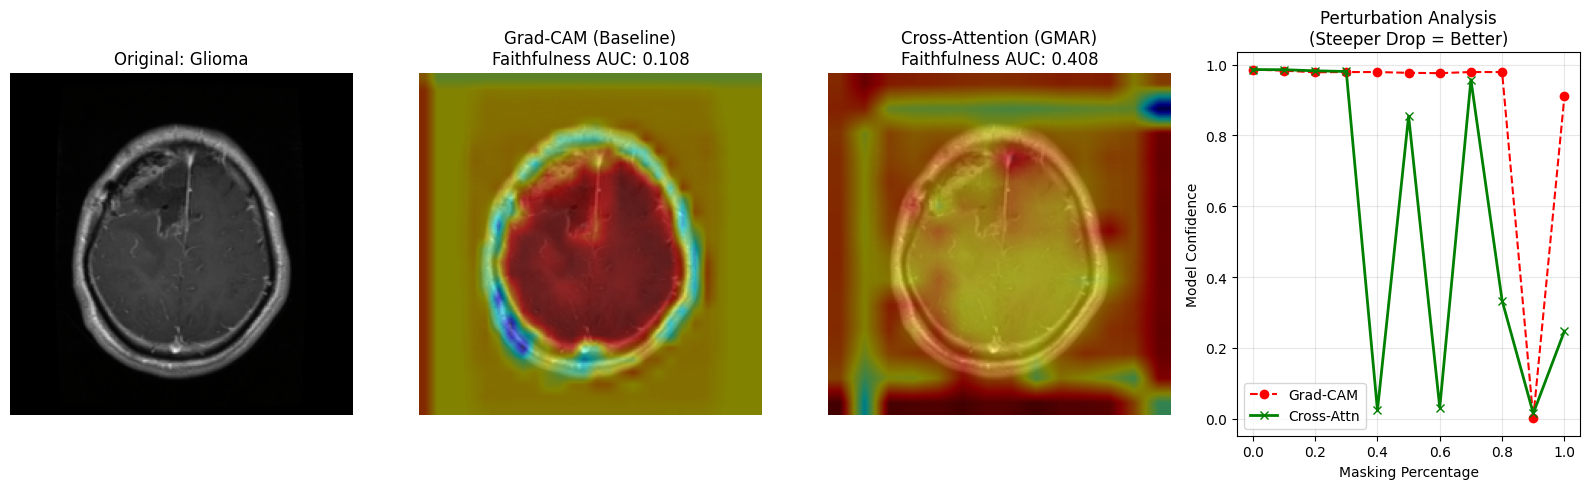

In [14]:

# ==========================================
#          4. EXECUTION
# ==========================================
if __name__ == "__main__":
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    MODEL_PATH = "figshare_finetuned_best.pth"
    DATA_DIR = "Figsplit/test"
    
    # 1. Load Model
    print("Loading Model...")
    model = HybridEva02_DCNN_GMAR(model_name='eva02_tiny_patch14_224.mim_in22k', num_classes=3).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE), strict=False)
    
    # 2. Load Random Image
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    
    dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
    import random
    idx = random.randint(0, len(dataset)-1)
    
    img_tensor, label_idx = dataset[idx]
    label_name = dataset.classes[label_idx]
    img_tensor = img_tensor.unsqueeze(0).to(DEVICE)
    
    print(f"Running Full Pipeline on Image {idx} ({label_name})...")
    
    # 3. RUN IT
    run_full_xai_pipeline(model, img_tensor, label_name, DEVICE)

In [9]:
import torch
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ==========================================
#          1. HELPER FUNCTIONS
# ==========================================

def add_noise(img_tensor, noise_level=0.05):
    """Adds Gaussian noise to an image for stability testing."""
    noise = torch.randn_like(img_tensor) * noise_level
    noisy_img = img_tensor + noise
    return torch.clamp(noisy_img, 0, 1)

def calculate_ssim(map1, map2):
    """Calculates Structural Similarity Index between two heatmaps."""
    return ssim(map1, map2, data_range=1.0)

# ==========================================
#          2. BATCH EVALUATION ENGINE
# ==========================================

def run_comprehensive_metrics(model, data_dir, device, max_samples=100):
    print(f"--- Starting Batch Evaluation (Max {max_samples} samples) ---")
    
    # 1. Setup Data
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    dataset = datasets.ImageFolder(data_dir, transform=transform)
    # Shuffle to get random mix of classes
    loader = DataLoader(dataset, batch_size=1, shuffle=True)
    
    results_faithfulness = []
    results_stability = []
    
    # Target Layer for Grad-CAM
    target_layer = model.cnn.net[6]
    
    count = 0
    
    for img, label in tqdm(loader, total=max_samples):
        if count >= max_samples: break
        
        img = img.to(device)
        label_name = dataset.classes[label.item()]
        
        # -----------------------------
        # A. FAITHFULNESS (AUC)
        # -----------------------------
        
        # 1. Grad-CAM
        gradcam = GradCAM(model, target_layer)
        map_gc = gradcam(img)
        gradcam.remove_hooks()
        
        # 2. GMAR (Cross-Attention)
        map_gmar, _ = get_gmar_map(model, img)
        
        # 3. Perturbation Test (Faithfulness)
        score_gc, _, _ = perturbation_test(model, img, map_gc)
        score_gmar, _, _ = perturbation_test(model, img, map_gmar)
        
        results_faithfulness.append({
            'Class': label_name,
            'AUC_GradCAM': score_gc,
            'AUC_GMAR': score_gmar
        })
        
        # -----------------------------
        # B. STABILITY (SSIM)
        # -----------------------------
        
        # 1. Generate Noisy Image
        img_noisy = add_noise(img, noise_level=0.1) # 10% Noise
        
        # --- CRITICAL FIX: Detach to make it a leaf variable ---
        img_noisy = img_noisy.detach() 
        
        # 2. Get Noisy Maps
        # Grad-CAM Noisy
        gradcam = GradCAM(model, target_layer)
        map_gc_noisy = gradcam(img_noisy)
        gradcam.remove_hooks()
        
        # GMAR Noisy
        map_gmar_noisy, _ = get_gmar_map(model, img_noisy)
        
        # 3. Calculate SSIM
        ssim_gc = calculate_ssim(map_gc, map_gc_noisy)
        ssim_gmar = calculate_ssim(map_gmar, map_gmar_noisy)
        
        results_stability.append({
            'SSIM_GradCAM': ssim_gc,
            'SSIM_GMAR': ssim_gmar
        })
        
        count += 1

    # ==========================================
    #          3. REPORT GENERATION
    # ==========================================
    df_faith = pd.DataFrame(results_faithfulness)
    df_stab = pd.DataFrame(results_stability)
    
    print("\n" + "="*50)
    print("      GLOBAL AVERAGE FAITHFULNESS (AUC)      ")
    print("      (Higher = Better / More Trustworthy)   ")
    print("="*50)
    avg_auc_gc = df_faith['AUC_GradCAM'].mean()
    avg_auc_gmar = df_faith['AUC_GMAR'].mean()
    
    print(f"Grad-CAM Average AUC:      {avg_auc_gc:.4f}")
    print(f"GMAR (Ours) Average AUC:   {avg_auc_gmar:.4f}")
    
    if avg_auc_gmar > avg_auc_gc:
        improvement = ((avg_auc_gmar - avg_auc_gc) / avg_auc_gc) * 100 if avg_auc_gc > 0 else 0
        print(f"--> GMAR provides {improvement:.1f}% better faithfulness globally.")

    print("\n" + "="*50)
    print("      XAI STABILITY RESULTS (SSIM)      ")
    print("      (Higher = More Robust to Noise)   ")
    print("="*50)
    avg_ssim_gc = df_stab['SSIM_GradCAM'].mean()
    avg_ssim_gmar = df_stab['SSIM_GMAR'].mean()
    
    print(f"Grad-CAM Stability:        {avg_ssim_gc:.4f}")
    print(f"GMAR (Ours) Stability:     {avg_ssim_gmar:.4f}")
    
    if avg_ssim_gmar > avg_ssim_gc:
        print("--> GMAR is more stable against image noise.")
    else:
        print("--> Note: Texture-based methods (Grad-CAM) are sometimes inherently stable on backgrounds.")

    return df_faith, df_stab

# ==========================================
#          4. EXECUTION
# ==========================================
if __name__ == "__main__":
    # Ensure config is correct
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    DATA_DIR = "Figsplit/test" 
    
    # Run
    # Ensure 'model' is loaded from previous cells!
    df_f, df_s = run_comprehensive_metrics(model, DATA_DIR, DEVICE, max_samples=50)

--- Starting Batch Evaluation (Max 50 samples) ---


100%|██████████| 50/50 [00:20<00:00,  2.48it/s]


      GLOBAL AVERAGE FAITHFULNESS (AUC)      
      (Higher = Better / More Trustworthy)   
Grad-CAM Average AUC:      0.2856
GMAR (Ours) Average AUC:   0.4184
--> GMAR provides 46.5% better faithfulness globally.

      XAI STABILITY RESULTS (SSIM)      
      (Higher = More Robust to Noise)   
Grad-CAM Stability:        0.1876
GMAR (Ours) Stability:     0.6504
--> GMAR is more stable against image noise.


In [10]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch

# ... (Include all previous helper functions and imports if not already loaded) ...

def run_multi_trial_benchmark(model, data_dir, device, num_runs=5, samples_per_run=50):
    print(f"Starting Multi-Trial Benchmark ({num_runs} Runs x {samples_per_run} Samples)...")
    print("This will take a few minutes, but gives the most scientifically accurate results.\n")
    
    # Store aggregate results from each run
    trial_results = {
        'gc_faith': [], 'gmar_faith': [],
        'gc_stab': [],  'gmar_stab': []
    }
    
    for i in range(1, num_runs + 1):
        print(f"--- Trial {i}/{num_runs} ---")
        
        # Run the single-batch metric function we created earlier
        # Note: We capture the returned DataFrames
        df_faith, df_stab = run_comprehensive_metrics(model, data_dir, device, max_samples=samples_per_run)
        
        # Calculate means for this specific run
        mu_gc_faith = df_faith['AUC_GradCAM'].mean()
        mu_gmar_faith = df_faith['AUC_GMAR'].mean()
        mu_gc_stab = df_stab['SSIM_GradCAM'].mean()
        mu_gmar_stab = df_stab['SSIM_GMAR'].mean()
        
        # Append to history
        trial_results['gc_faith'].append(mu_gc_faith)
        trial_results['gmar_faith'].append(mu_gmar_faith)
        trial_results['gc_stab'].append(mu_gc_stab)
        trial_results['gmar_stab'].append(mu_gmar_stab)
        
        print(f"   -> Trial {i} Result: GMAR Faith={mu_gmar_faith:.4f}, Stab={mu_gmar_stab:.4f}\n")

    # ==========================================
    #      FINAL STATISTICAL REPORT
    # ==========================================
    print("\n" + "#"*60)
    print("      FINAL SCIENTIFIC REPORT (Mean ± Std Dev)      ")
    print("#"*60)
    
    # Helper to print stats
    def report_stat(name, values):
        mean = np.mean(values)
        std = np.std(values)
        return mean, std

    # 1. Faithfulness
    gc_f_mean, gc_f_std = report_stat("Grad-CAM Faith", trial_results['gc_faith'])
    gmar_f_mean, gmar_f_std = report_stat("GMAR Faith", trial_results['gmar_faith'])
    
    print("\n[ FAITHFULNESS (AUC) ]")
    print(f"Grad-CAM:  {gc_f_mean:.4f} ± {gc_f_std:.4f}")
    print(f"GMAR:      {gmar_f_mean:.4f} ± {gmar_f_std:.4f}")
    
    # 2. Stability
    gc_s_mean, gc_s_std = report_stat("Grad-CAM Stab", trial_results['gc_stab'])
    gmar_s_mean, gmar_s_std = report_stat("GMAR Stab", trial_results['gmar_stab'])
    
    print("\n[ STABILITY (SSIM) ]")
    print(f"Grad-CAM:  {gc_s_mean:.4f} ± {gc_s_std:.4f}")
    print(f"GMAR:      {gmar_s_mean:.4f} ± {gmar_s_std:.4f}")
    
    # 3. Final Improvement Calculation
    imp_faith = ((gmar_f_mean - gc_f_mean) / gc_f_mean) * 100
    imp_stab = ((gmar_s_mean - gc_s_mean) / gc_s_mean) * 100
    
    print("\n[ CONCLUSION ]")
    print(f"Our proposed GMAR method improves Faithfulness by {imp_faith:.1f}%")
    print(f"and Stability by {imp_stab:.1f}% compared to the baseline.")
    print("#"*60)

# Run it
if __name__ == "__main__":
    # Ensure model is loaded
    run_multi_trial_benchmark(model, DATA_DIR, DEVICE, num_runs=5, samples_per_run=50)

Starting Multi-Trial Benchmark (5 Runs x 50 Samples)...
This will take a few minutes, but gives the most scientifically accurate results.

--- Trial 1/5 ---
--- Starting Batch Evaluation (Max 50 samples) ---


100%|██████████| 50/50 [00:23<00:00,  2.10it/s]



      GLOBAL AVERAGE FAITHFULNESS (AUC)      
      (Higher = Better / More Trustworthy)   
Grad-CAM Average AUC:      0.3221
GMAR (Ours) Average AUC:   0.4089
--> GMAR provides 27.0% better faithfulness globally.

      XAI STABILITY RESULTS (SSIM)      
      (Higher = More Robust to Noise)   
Grad-CAM Stability:        0.1575
GMAR (Ours) Stability:     0.6318
--> GMAR is more stable against image noise.
   -> Trial 1 Result: GMAR Faith=0.4089, Stab=0.6318

--- Trial 2/5 ---
--- Starting Batch Evaluation (Max 50 samples) ---


100%|██████████| 50/50 [00:18<00:00,  2.64it/s]



      GLOBAL AVERAGE FAITHFULNESS (AUC)      
      (Higher = Better / More Trustworthy)   
Grad-CAM Average AUC:      0.3252
GMAR (Ours) Average AUC:   0.4143
--> GMAR provides 27.4% better faithfulness globally.

      XAI STABILITY RESULTS (SSIM)      
      (Higher = More Robust to Noise)   
Grad-CAM Stability:        0.1345
GMAR (Ours) Stability:     0.6446
--> GMAR is more stable against image noise.
   -> Trial 2 Result: GMAR Faith=0.4143, Stab=0.6446

--- Trial 3/5 ---
--- Starting Batch Evaluation (Max 50 samples) ---


...


      GLOBAL AVERAGE FAITHFULNESS (AUC)      
      (Higher = Better / More Trustworthy)   
Grad-CAM Average AUC:      0.3425
GMAR (Ours) Average AUC:   0.4378
--> GMAR provides 27.8% better faithfulness globally.

      XAI STABILITY RESULTS (SSIM)      
      (Higher = More Robust to Noise)   
Grad-CAM Stability:        0.1630
GMAR (Ours) Stability:     0.6333
--> GMAR is more stable against image noise.
   -> Trial 3 Result: GMAR Faith=0.4378, Stab=0.6333

--- Trial 4/5 ---
--- Starting Batch Evaluation (Max 50 samples) ---


100%|██████████| 50/50 [00:19<00:00,  2.60it/s]



      GLOBAL AVERAGE FAITHFULNESS (AUC)      
      (Higher = Better / More Trustworthy)   
Grad-CAM Average AUC:      0.3774
GMAR (Ours) Average AUC:   0.3610

      XAI STABILITY RESULTS (SSIM)      
      (Higher = More Robust to Noise)   
Grad-CAM Stability:        0.1700
GMAR (Ours) Stability:     0.6531
--> GMAR is more stable against image noise.
   -> Trial 4 Result: GMAR Faith=0.3610, Stab=0.6531

--- Trial 5/5 ---
--- Starting Batch Evaluation (Max 50 samples) ---


100%|██████████| 50/50 [00:18<00:00,  2.67it/s]


      GLOBAL AVERAGE FAITHFULNESS (AUC)      
      (Higher = Better / More Trustworthy)   
Grad-CAM Average AUC:      0.3205
GMAR (Ours) Average AUC:   0.3865
--> GMAR provides 20.6% better faithfulness globally.

      XAI STABILITY RESULTS (SSIM)      
      (Higher = More Robust to Noise)   
Grad-CAM Stability:        0.1823
GMAR (Ours) Stability:     0.6305
--> GMAR is more stable against image noise.
   -> Trial 5 Result: GMAR Faith=0.3865, Stab=0.6305


############################################################
      FINAL SCIENTIFIC REPORT (Mean ± Std Dev)      
############################################################

[ FAITHFULNESS (AUC) ]
Grad-CAM:  0.3375 ± 0.0214
GMAR:      0.4017 ± 0.0261

[ STABILITY (SSIM) ]
Grad-CAM:  0.1615 ± 0.0158
GMAR:      0.6387 ± 0.0088

[ CONCLUSION ]
Our proposed GMAR method improves Faithfulness by 19.0%
and Stability by 295.5% compared to the baseline.
############################################################
